In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
import glob

from scipy.ndimage import gaussian_filter
from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

import requests
from PIL import Image 
import numpy as np
from io import BytesIO

In [1]:
import os
os.environ["SPS_HOME"] = "FSPS/"

import fsps
sp = fsps.StellarPopulation(compute_vega_mags=False, zcontinuous=1,
                                sfh=0, logzsol=0.0, dust_type=2, dust2=0.2)

In [164]:
df

,Bandpass,Magnitude,Unc High,Unc Low,Unit,Frequency (Hz),Flux Density,FD Unc High,FD Unc Low,Flux,F Unc High,F Unc Low,Telescope
0,FUV (GALEX) AB,13.83,0.01,0.01,mag,1.960000e+15,0.010670,0.000098,0.000098,2.091320e+13,1.925504e+11,1.925504e+11,GALEX
1,NUV (GALEX) AB,14.12,0.01,0.01,mag,1.320000e+15,0.008166,0.000075,0.000075,1.077912e+13,9.927720e+10,9.927720e+10,GALEX
2,u (SDSS) AB,13.37,0.05,0.05,mag,8.440000e+14,0.016290,0.000750,0.000750,1.374876e+13,6.329156e+11,6.329156e+11,2.5m
3,g (SDSS) AB,11.98,0.05,0.05,mag,6.400000e+14,0.058470,0.002693,0.002693,3.742080e+13,1.723520e+12,1.723520e+12,2.5m
4,r (SDSS) AB,11.88,0.05,0.05,mag,4.860000e+14,0.064120,0.002953,0.002953,3.116232e+13,1.435158e+12,1.435158e+12,2.5m
5,i (SDSS) AB,11.46,0.05,0.05,mag,4.010000e+14,0.094640,0.004358,0.004358,3.795064e+13,1.747558e+12,1.747558e+12,2.5m
6,z (SDSS) AB,11.36,0.05,0.05,mag,3.360000e+14,0.103600,0.004770,0.004770,3.480960e+13,1.602720e+12,1.602720e+12,2.5m
7,J (2MASS) AB,11.19,0.05,0.05,mag,2.430000e+14,0.121600,0.005600,0.005600,2.954880e+13,1.360800e+12,1.360800e+12,1.3m
8,H (2MASS) AB,11.06,0.05,0.05,mag,1.820000e+14,0.136400,0.006283,0.006283,2.482480e+13,1.143506e+12,1.143506e+12,1.3m
9,Ks (2MASS) AB,11.34,0.05,0.05,mag,1.390000e+14,0.106000,0.004881,0.004881,1.473400e+13,6.784590e+11,6.784590e+11,1.3m


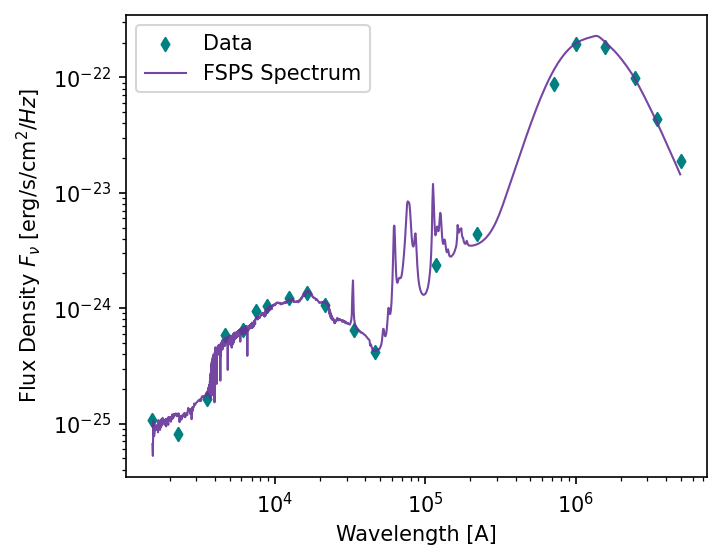

In [175]:
df = pd.read_csv('mystery_galaxy_sed.tsv', sep='\t')
wv = 3e8 / df['Frequency (Hz)'].values * 1e10
fl = df['Flux Density'].values * 1e-23 #* df['Frequency (Hz)'].values

plt.figure(figsize=(5,4), dpi=150)
plt.xscale('log')
plt.yscale('log')
plt.scatter(wv, fl, color='teal', marker='d', s=20, label='Data')
plt.xlabel('Wavelength [A]')
plt.ylabel(r'Flux Density $F_\nu$ [erg/s/cm$^2/Hz$]')

sps = fsps.StellarPopulation(sfh=1, tau=1.5, zcontinuous=1)
sps.params['dust_type'] = 0
sps.params['const'] = 0.
sps.params['sf_trunc']= 3
sps.params['dust1'] = 0.
sps.params['dust2'] = 0.5
sps.params['gas_logz'] = -0.5  # Gas Z
sps.params['gas_logu'] = -2.0  # Ionization parameter [web:7]
sps.params['logzsol'] = 0
sps.params["duste_gamma"] = 0.00
sps.params["duste_umin"] = 3.6
sps.params["agb_dust"] = 0. 
sps.params["tburst"] = 0.4
sps.params["fbhb"] = 1
lam, spec = sps.get_spectrum(tage=2)
spec = spec * 2e33 / (4 *np.pi * (20*3.086e18*1e6)**2)
mask = np.where((lam>=wv.min()) & (lam<=wv.max()))[0]
plt.plot(lam[mask], spec[mask]*1e10, color='rebeccapurple', alpha=0.9, lw=1, label='FSPS Spectrum')
plt.legend()

In [90]:
sps.params['sf_start']

9